# Step 7 & 8: Stunting Prediction Modeling and Explainable AI

This notebook trains machine learning models for early stunting risk prediction, evaluates model performance, performs threshold tuning, and applies SHAP and LIME for model interpretation.


## 1. Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, make_scorer
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.titleweight": "bold"
})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "Data/processed/dataset_final.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = MODEL_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False

RANDOM_STATE = 42


## 2. Load Dataset

The dataset used in this step is the machine-learning-ready dataset from Step 6.


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


Dataset shape: 4886 rows and 19 columns


,child_gender,mother_education_level,mother_employment_status,mother_height_cm,improved_water,improved_sanitation,home_ownership,has_electricity,has_refrigerator,has_tv,is_stunted,mother_age_at_birth,is_teenage_mother,is_high_risk_mother_age,has_delivery_insurance,anc_clinic_midwife,anc_hospital,anc_traditional_other,anc_unknown
0,1,0,1,156.6,1.0,0.0,1.0,0.0,0.0,0.0,1,35.333333,0,1,0,0,0,0,1
1,1,1,0,151.6,1.0,0.0,1.0,0.0,0.0,0.0,1,36.750000,0,1,0,0,0,0,1
2,1,2,1,147.6,1.0,0.0,1.0,0.0,0.0,0.0,1,31.000000,0,0,0,0,0,0,1
3,0,0,0,140.1,1.0,0.0,1.0,0.0,0.0,0.0,0,30.416667,0,0,0,0,0,0,1
4,1,1,0,156.4,1.0,0.0,1.0,0.0,0.0,0.0,1,29.500000,0,0,0,0,0,0,1


## 3. Dataset Overview


In [3]:
display(df.describe())

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values)

print("\nTarget distribution:")
display(df["is_stunted"].value_counts())

print("\nTarget distribution percentage:")
display((df["is_stunted"].value_counts(normalize=True) * 100).round(2))


,child_gender,mother_education_level,mother_employment_status,mother_height_cm,improved_water,improved_sanitation,home_ownership,has_electricity,has_refrigerator,has_tv,is_stunted,mother_age_at_birth,is_teenage_mother,is_high_risk_mother_age,has_delivery_insurance,anc_clinic_midwife,anc_hospital,anc_traditional_other,anc_unknown
count,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000
mean,0.518625,2.552804,0.333402,151.696050,0.981989,0.748874,0.670692,0.991199,0.448629,0.922841,0.326852,27.328302,0.110725,0.148588,0.345068,0.481171,0.287147,0.006140,0.225542
std,0.499704,1.225612,0.471477,5.438581,0.133003,0.433705,0.470010,0.093408,0.497405,0.266871,0.469111,5.900061,0.313823,0.355718,0.475439,0.499696,0.452477,0.078125,0.417982
min,0.000000,0.000000,0.000000,104.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,148.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,22.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,0.000000,151.600000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,27.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,155.300000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,31.416667,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,5.000000,1.000000,174.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,50.916667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


No missing values found.

Target distribution:


is_stunted
0    3289
1    1597
Name: count, dtype: int64


Target distribution percentage:


is_stunted
0    67.31
1    32.69
Name: proportion, dtype: float64

## 4. Feature Engineering Summary

The final dataset includes engineered predictors such as mother_age_at_birth, teenage mother indicator, high-risk maternal age indicator, delivery insurance status, and one-hot encoded ANC location. These variables are designed to represent maternal, socioeconomic, and prenatal risk factors.


## 5. Exploratory Data Analysis


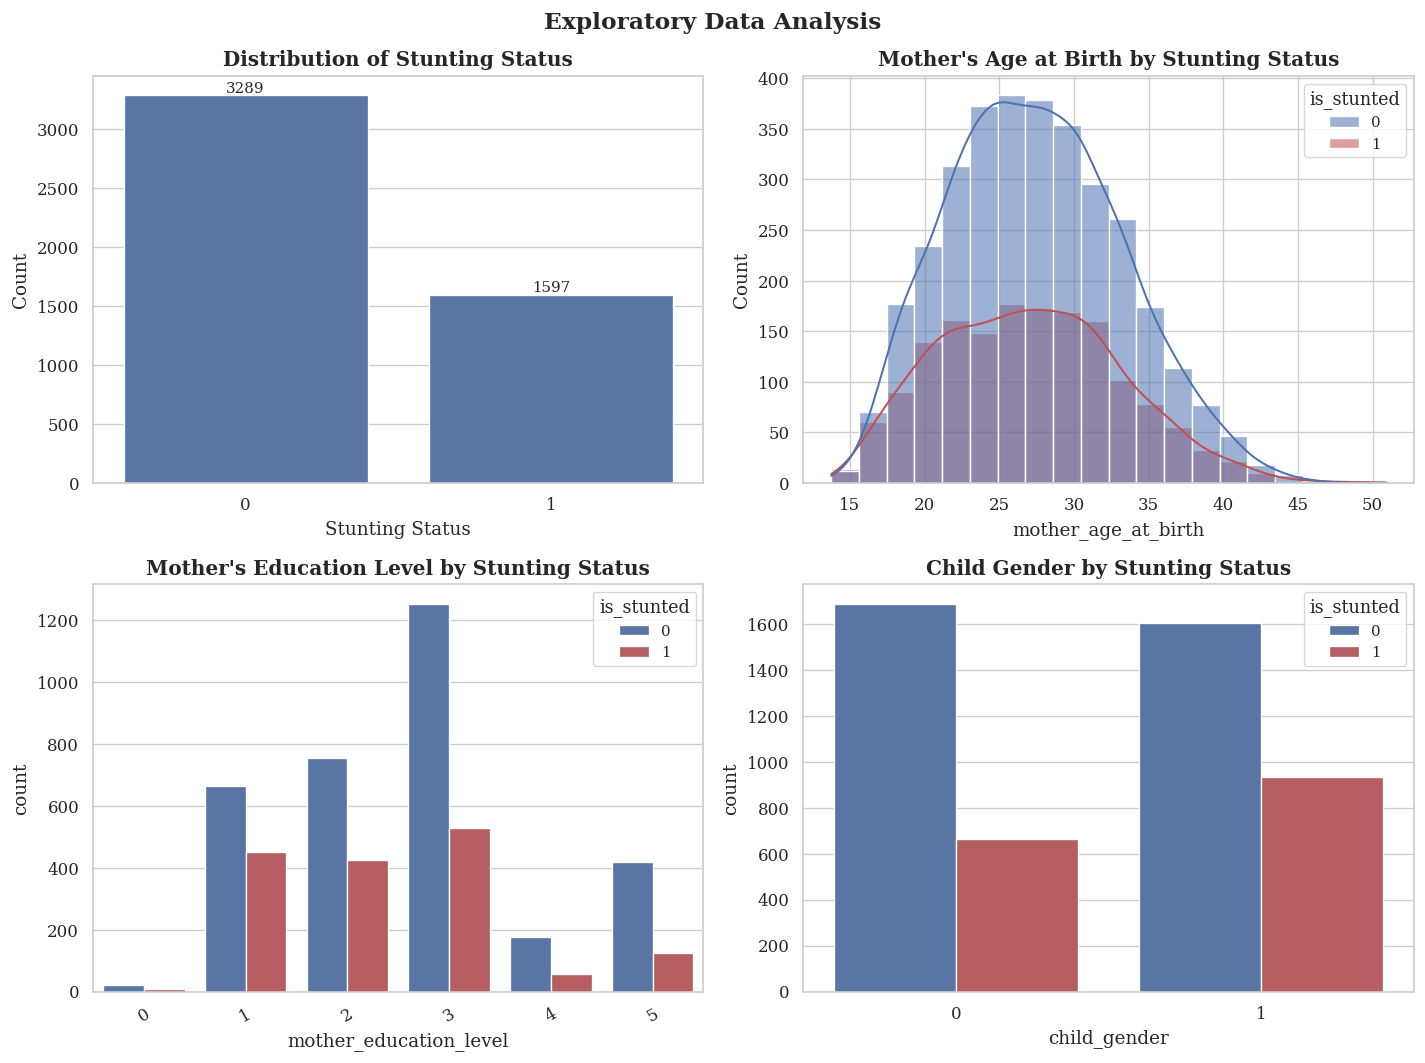

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold")

sns.countplot(data=df, x="is_stunted", ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribution of Stunting Status")
axes[0, 0].set_xlabel("Stunting Status")
axes[0, 0].set_ylabel("Count")
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fontsize=9)

sns.histplot(
    data=df,
    x="mother_age_at_birth",
    hue="is_stunted",
    kde=True,
    bins=20,
    ax=axes[0, 1],
    palette=["#4C72B0", "#C44E52"],
    alpha=0.55
)
axes[0, 1].set_title("Mother's Age at Birth by Stunting Status")

sns.countplot(
    data=df,
    x="mother_education_level",
    hue="is_stunted",
    ax=axes[1, 0],
    palette=["#4C72B0", "#C44E52"]
)
axes[1, 0].set_title("Mother's Education Level by Stunting Status")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.countplot(
    data=df,
    x="child_gender",
    hue="is_stunted",
    ax=axes[1, 1],
    palette=["#4C72B0", "#C44E52"]
)
axes[1, 1].set_title("Child Gender by Stunting Status")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_overview.png", bbox_inches="tight")
plt.show()


## 6. Feature Correlation Analysis


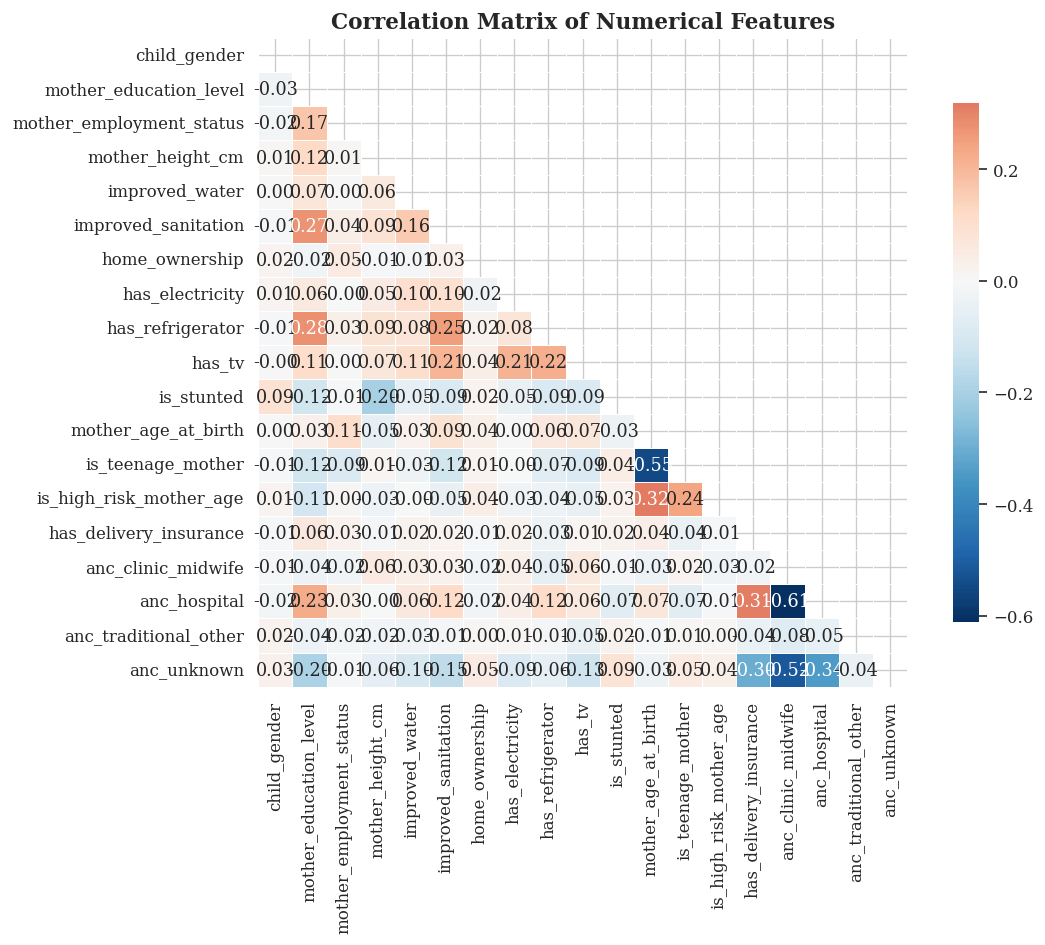

In [5]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_matrix.png", bbox_inches="tight")
plt.show()


## 7. Train-Test Split

The dataset is split using an 80:20 stratified split to preserve the target class distribution.


In [6]:
X = df.drop(columns=["is_stunted"])
y = df["is_stunted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

print("\nTraining target distribution:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
display((y_test.value_counts(normalize=True) * 100).round(2))


Training set: 3908 samples
Testing set: 978 samples

Training target distribution:


is_stunted
0    67.32
1    32.68
Name: proportion, dtype: float64


Testing target distribution:


is_stunted
0    67.28
1    32.72
Name: proportion, dtype: float64

## 8. Cross-Validation

Five-fold stratified cross-validation is used to estimate model generalization more robustly.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )

scoring = {
    "accuracy": "accuracy",
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "Model": name,
        "Accuracy": f"{res['test_accuracy'].mean():.3f} +/- {res['test_accuracy'].std():.3f}",
        "Recall": f"{res['test_recall'].mean():.3f} +/- {res['test_recall'].std():.3f}",
        "F1": f"{res['test_f1'].mean():.3f} +/- {res['test_f1'].std():.3f}",
        "ROC-AUC": f"{res['test_roc_auc'].mean():.3f} +/- {res['test_roc_auc'].std():.3f}",
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df)


,Model,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.613 +/- 0.015,0.599 +/- 0.025,0.503 +/- 0.015,0.659 +/- 0.015
1,Random Forest,0.660 +/- 0.007,0.248 +/- 0.021,0.323 +/- 0.021,0.616 +/- 0.013
2,XGBoost,0.617 +/- 0.011,0.418 +/- 0.014,0.416 +/- 0.011,nan +/- nan


## 9. Model Training and Evaluation


In [8]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    }

metrics_df = pd.DataFrame({
    name: [
        r["accuracy"],
        r["precision"],
        r["recall"],
        r["f1"],
        r["auc"]
    ]
    for name, r in results.items()
}, index=["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]).T

display(metrics_df.round(4))

for name, r in results.items():
    print(f"\nClassification Report: {name}")
    print(classification_report(y_test, r["y_pred"]))


Training Logistic Regression...
Training Random Forest...


Training XGBoost...


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.6104,0.4350,0.6375,0.5171,0.6561
Random Forest,0.6575,0.4571,0.2500,0.3232,0.6178
XGBoost,0.6196,0.4207,0.4312,0.4259,0.6067



Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.60      0.67       658
           1       0.43      0.64      0.52       320

    accuracy                           0.61       978
   macro avg       0.60      0.62      0.60       978
weighted avg       0.66      0.61      0.62       978


Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       658
           1       0.46      0.25      0.32       320

    accuracy                           0.66       978
   macro avg       0.58      0.55      0.55       978
weighted avg       0.62      0.66      0.62       978


Classification Report: XGBoost
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       658
           1       0.42      0.43      0.43       320

    accuracy                           0.62       978
   macro avg  

## 10. Model Comparison Visualization


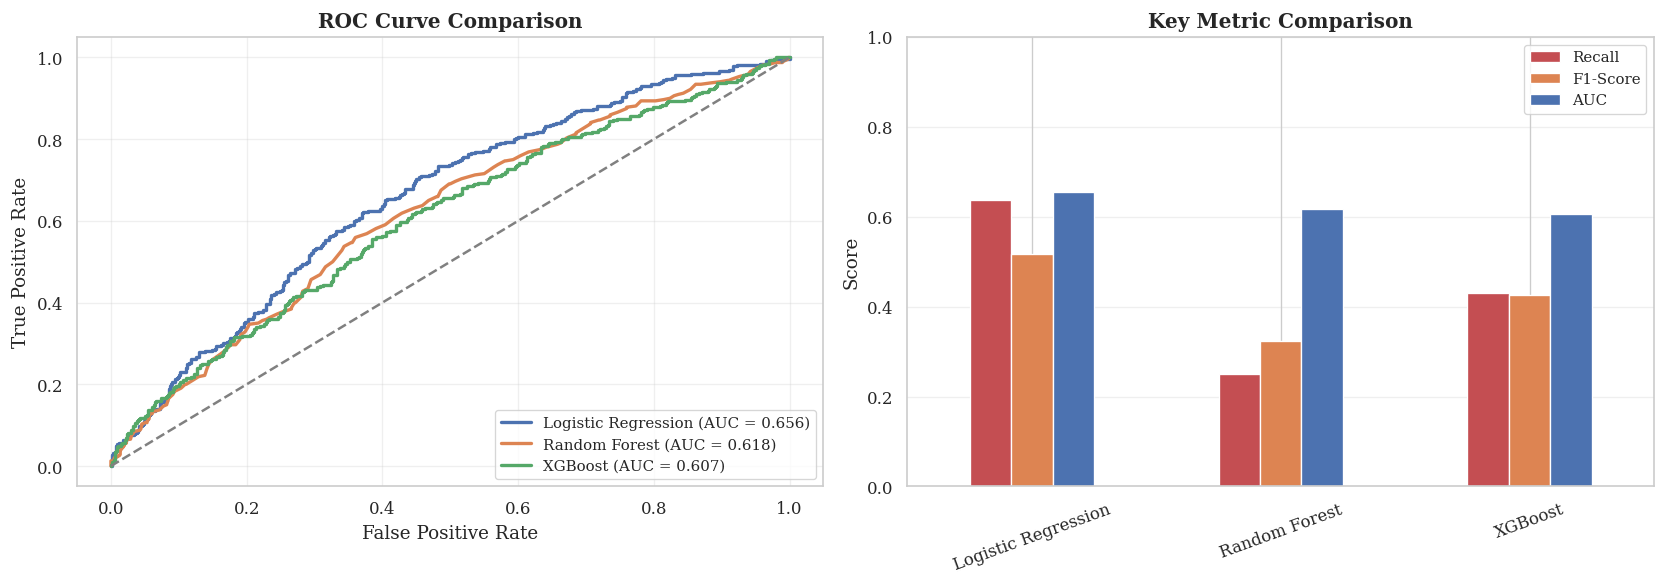

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {r['auc']:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="gray")
axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

metric_plot = metrics_df[["Recall", "F1-Score", "AUC"]].copy()
metric_plot.plot(kind="bar", ax=axes[1], color=["#C44E52", "#DD8452", "#4C72B0"])

axes[1].set_title("Key Metric Comparison")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()


## 11. Confusion Matrix


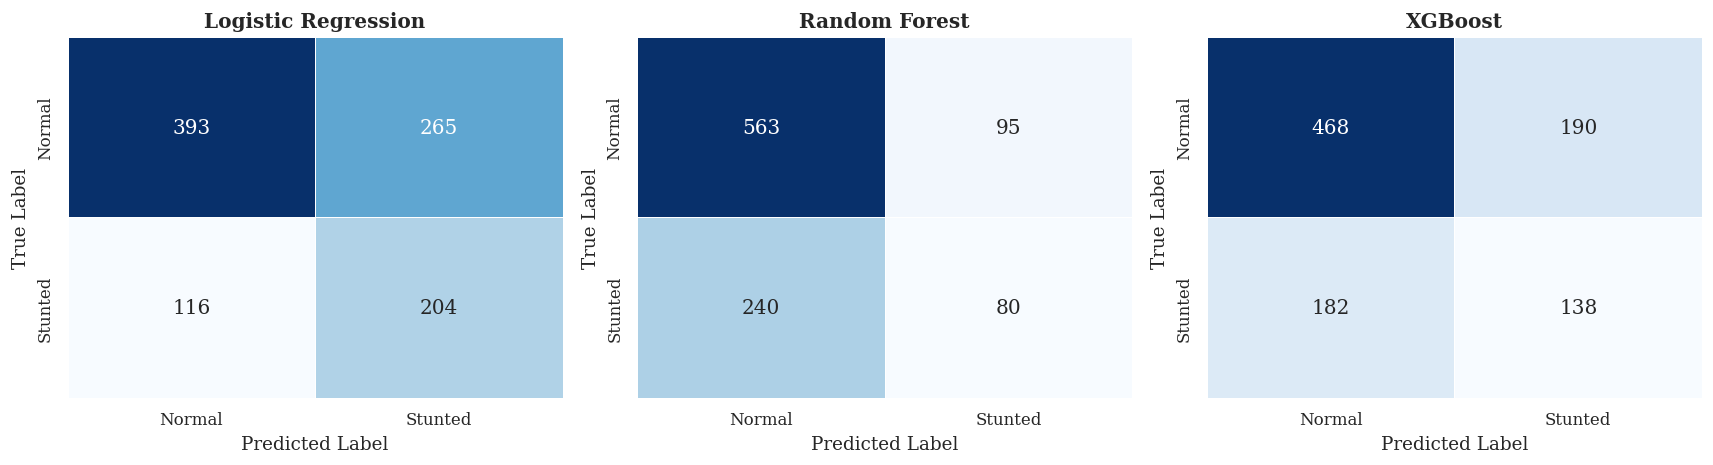

In [10]:
fig_cm, axes_cm = plt.subplots(1, len(results), figsize=(4.8 * len(results), 4))

if len(results) == 1:
    axes_cm = [axes_cm]

for ax, (name, r) in zip(axes_cm, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        linewidths=0.5,
        annot_kws={"size": 12},
        xticklabels=["Normal", "Stunted"],
        yticklabels=["Normal", "Stunted"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()


## 12. Best Model Selection

The best model is selected by prioritizing F1-Score, Recall, and AUC for the stunted class.


In [11]:
best_name = max(results, key=lambda x: (results[x]["f1"], results[x]["recall"], results[x]["auc"]))
best_model = results[best_name]["model"]

print(f"Best model: {best_name}")
print(f"F1-Score: {results[best_name]['f1']:.4f}")
print(f"Recall:   {results[best_name]['recall']:.4f}")
print(f"AUC:      {results[best_name]['auc']:.4f}")


Best model: Logistic Regression
F1-Score: 0.5171
Recall:   0.6375
AUC:      0.6561


## 13. Threshold Tuning

Threshold tuning is applied to support screening by improving sensitivity to stunting risk.


In [12]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
tuning_rows = []
y_best_prob = results[best_name]["y_prob"]

for threshold in thresholds:
    pred_threshold = (y_best_prob >= threshold).astype(int)
    tuning_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred_threshold),
        "Recall": recall_score(y_test, pred_threshold),
        "F1-Score": f1_score(y_test, pred_threshold)
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df.round(4))

best_tune = tuning_df.loc[tuning_df["F1-Score"].idxmax()]
optimal_threshold = float(best_tune["Threshold"])

print(f"Optimal threshold: {optimal_threshold}")
print(f"Precision: {best_tune['Precision']:.4f}")
print(f"Recall: {best_tune['Recall']:.4f}")
print(f"F1-Score: {best_tune['F1-Score']:.4f}")


,Threshold,Precision,Recall,F1-Score
0,0.30,0.3472,0.9625,0.5104
1,0.35,0.3651,0.9219,0.5230
2,0.40,0.3837,0.8406,0.5269
3,0.45,0.4126,0.7594,0.5347
4,0.50,0.4350,0.6375,0.5171


Optimal threshold: 0.45
Precision: 0.4126
Recall: 0.7594
F1-Score: 0.5347


## 14. Save Model Artifacts


In [13]:
comparison = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "ROC-AUC": r["auc"]
    }
    for name, r in results.items()
])

joblib.dump(best_model, MODEL_DIR / "stunting_model.pkl")
joblib.dump(list(X.columns), MODEL_DIR / "feature_columns.pkl")
joblib.dump(optimal_threshold, MODEL_DIR / "stunting_threshold.pkl")

comparison.to_csv(PROJECT_ROOT / "Data/processed/07_model_comparison.csv", index=False)
tuning_df.to_csv(PROJECT_ROOT / "Data/processed/07_threshold_tuning.csv", index=False)

print("All Step 7 artifacts saved.")


All Step 7 artifacts saved.


---

# Step 8: Explainable AI

SHAP is used as the primary XAI method because it supports both global and local interpretation. LIME is used as a local comparison method.


## 15. SHAP Global Interpretability


In [14]:
if not SHAP_AVAILABLE:
    raise ImportError("SHAP is not installed. Run: pip install shap")

if isinstance(best_model, LogisticRegression):
    explainer = shap.LinearExplainer(best_model, X_train)
else:
    explainer = shap.TreeExplainer(best_model)

shap_values_raw = explainer.shap_values(X_test)

if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
else:
    shap_vals = shap_values_raw

print("SHAP values shape:", np.array(shap_vals).shape)


SHAP values shape: (978, 18)


## 16. SHAP Summary Plot


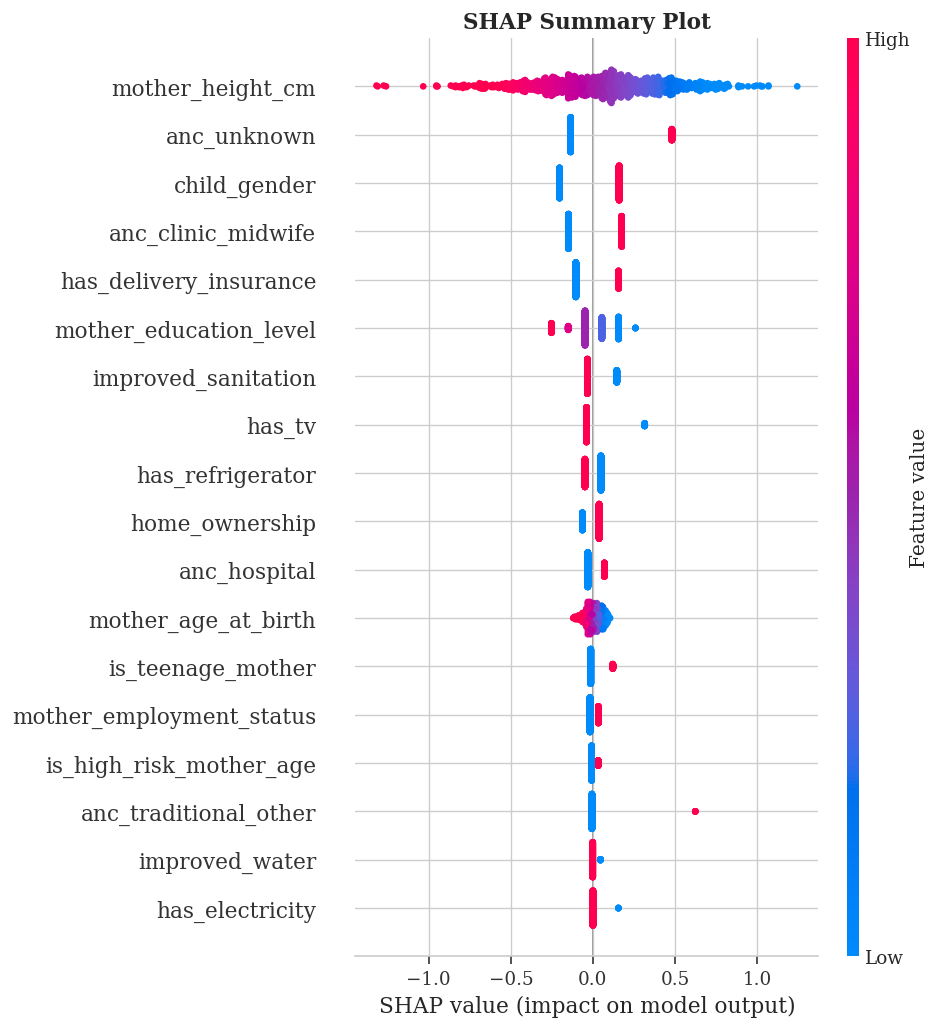

In [15]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test, show=False)
plt.title("SHAP Summary Plot", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_summary.png", bbox_inches="tight", dpi=300)
plt.show()


## 17. SHAP Feature Importance


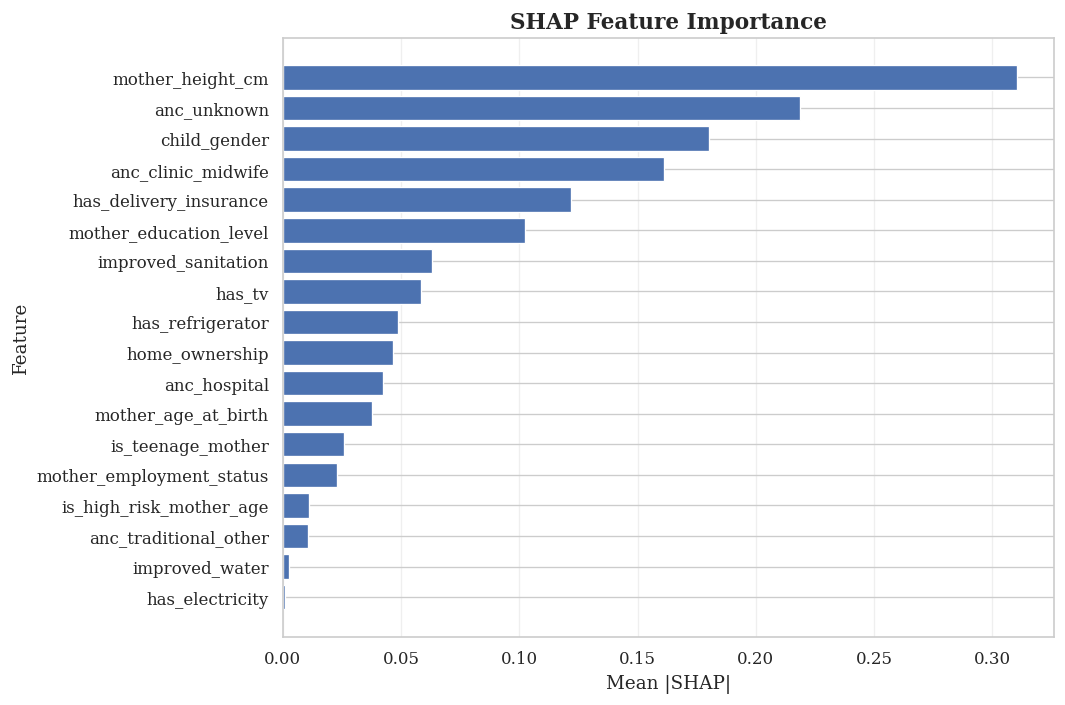

,Feature,Mean |SHAP|
3,mother_height_cm,0.310520
17,anc_unknown,0.218791
0,child_gender,0.180022
14,anc_clinic_midwife,0.160970
13,has_delivery_insurance,0.121674
1,mother_education_level,0.102512
5,improved_sanitation,0.062882
9,has_tv,0.058442
8,has_refrigerator,0.048693
6,home_ownership,0.046633


In [16]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(shap_importance["Feature"], shap_importance["Mean |SHAP|"], color="#4C72B0")
plt.xlabel("Mean |SHAP|")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance", fontsize=13, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_feature_importance.png", bbox_inches="tight", dpi=300)
plt.show()

shap_importance_sorted = shap_importance.sort_values("Mean |SHAP|", ascending=False)
display(shap_importance_sorted)

shap_importance_sorted.to_csv(
    PROJECT_ROOT / "Data/processed/08_shap_feature_importance.csv",
    index=False
)


## 18. SHAP Waterfall Plot

This plot explains one stunted sample by showing how each feature pushes the prediction toward or away from stunting risk.


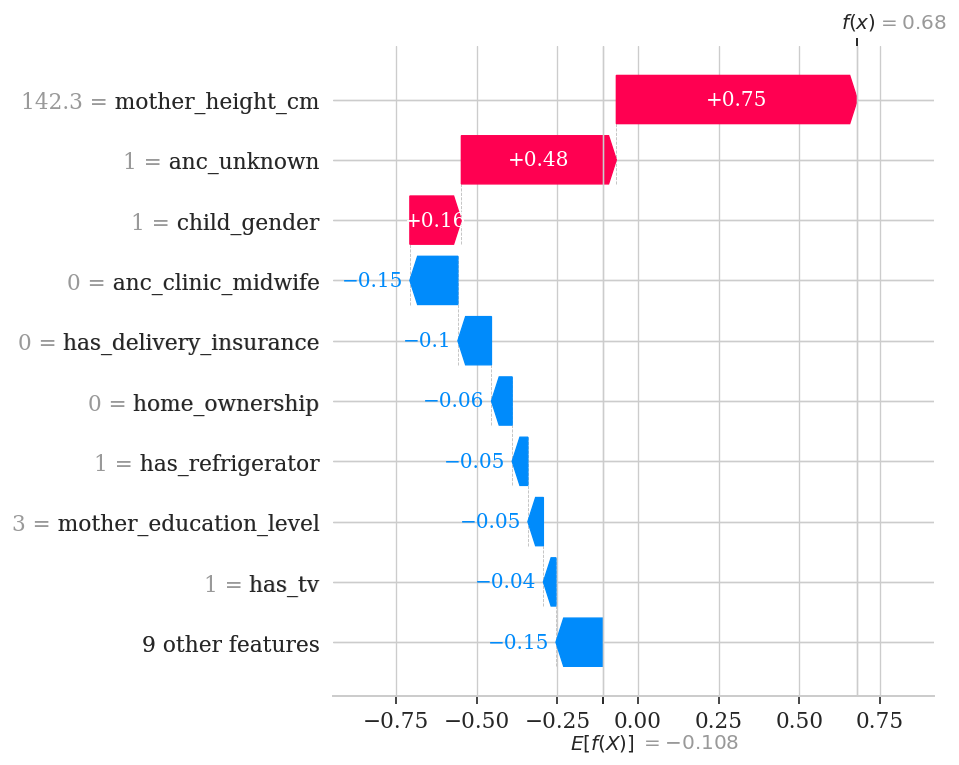

In [17]:
stunted_indices = np.where(y_test.values == 1)[0]

if len(stunted_indices) == 0:
    sample_idx = 0
else:
    sample_idx = stunted_indices[0]

sample_x = X_test.iloc[sample_idx]

if isinstance(best_model, LogisticRegression):
    base_value = explainer.expected_value
else:
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        base_value = expected_value[1]
    else:
        base_value = expected_value

explanation = shap.Explanation(
    values=shap_vals[sample_idx],
    base_values=base_value,
    data=sample_x.values,
    feature_names=list(X.columns)
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_waterfall_sample.png", bbox_inches="tight", dpi=300)
plt.show()


## 19. LIME Local Explanation

LIME is used as a local comparison method for the same sample explained by SHAP.


In [18]:
if not LIME_AVAILABLE:
    raise ImportError("LIME is not installed. Run: pip install lime")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Normal", "Stunted"],
    mode="classification",
    random_state=RANDOM_STATE
)

exp = lime_explainer.explain_instance(
    data_row=sample_x.values,
    predict_fn=best_model.predict_proba,
    num_features=len(X.columns)
)

lime_df = pd.DataFrame(exp.as_list(), columns=["Feature Rule", "Weight"])
lime_df["Direction"] = np.where(lime_df["Weight"] > 0, "Increases stunting risk", "Decreases stunting risk")
lime_df["Abs Weight"] = lime_df["Weight"].abs()
lime_df = lime_df.sort_values("Abs Weight", ascending=True)

display(lime_df.sort_values("Abs Weight", ascending=False).head(10))


,Feature Rule,Weight,Direction,Abs Weight
0,mother_height_cm <= 148.00,0.170904,Increases stunting risk,0.170904
1,anc_unknown > 0.00,0.142068,Increases stunting risk,0.142068
2,anc_traditional_other <= 0.00,-0.103594,Decreases stunting risk,0.103594
3,0.00 < child_gender <= 1.00,0.085520,Increases stunting risk,0.085520
4,anc_clinic_midwife <= 0.00,-0.077816,Decreases stunting risk,0.077816
5,has_delivery_insurance <= 0.00,-0.060221,Decreases stunting risk,0.060221
6,anc_hospital <= 0.00,-0.026044,Decreases stunting risk,0.026044
7,home_ownership <= 0.00,-0.025213,Decreases stunting risk,0.025213
8,is_teenage_mother <= 0.00,-0.024057,Decreases stunting risk,0.024057
9,0.00 < has_refrigerator <= 1.00,-0.023321,Decreases stunting risk,0.023321


## 20. LIME Visualization


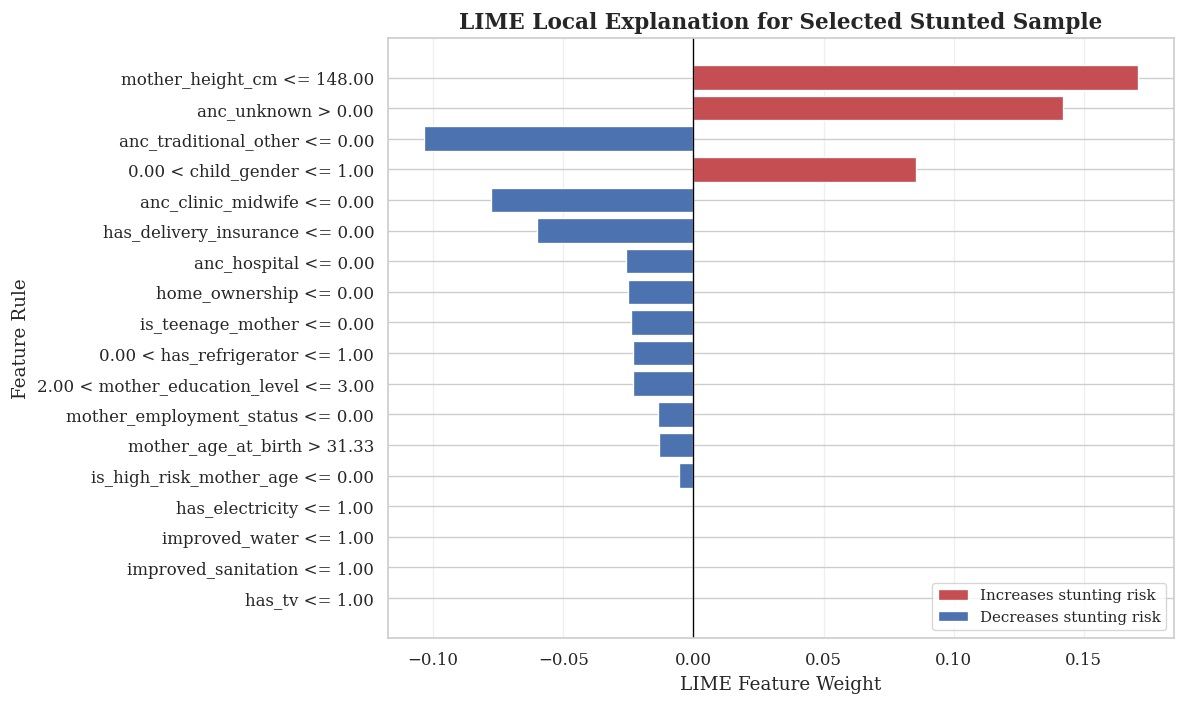

In [19]:
colors = lime_df["Weight"].apply(lambda x: "#C44E52" if x > 0 else "#4C72B0")

plt.figure(figsize=(10, 6))
plt.barh(lime_df["Feature Rule"], lime_df["Weight"], color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("LIME Feature Weight")
plt.ylabel("Feature Rule")
plt.title("LIME Local Explanation for Selected Stunted Sample", fontsize=13, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C44E52", label="Increases stunting risk"),
    Patch(facecolor="#4C72B0", label="Decreases stunting risk")
]
plt.legend(handles=legend_elements, loc="lower right")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lime_explanation_sample.png", bbox_inches="tight", dpi=300)
plt.show()


## 21. SHAP vs LIME Comparison

| Method | Interpretation | Strengths | Weaknesses | Role |
|---|---|---|---|---|
| **SHAP** | Global + Local | Mathematically grounded and consistent feature attribution | Higher computational cost | Primary XAI method |
| **LIME** | Local only | Intuitive and easy to explain for one prediction | Less stable due to local sampling | Local comparison |


## 22. XAI Validation Summary


In [20]:
print(f"Best model: {best_name}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print(f"LIME available: {LIME_AVAILABLE}")

print("\nSaved figures:")
for fig_path in sorted(FIGURE_DIR.glob("*.png")):
    print(fig_path)

print("\nSaved artifacts:")
for artifact_path in sorted(MODEL_DIR.glob("*.pkl")):
    print(artifact_path)


Best model: Logistic Regression
X_train shape: (3908, 18)
X_test shape: (978, 18)
Number of features: 18
SHAP available: True
LIME available: True

Saved figures:
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/confusion_matrices.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/correlation_matrix.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/eda_overview.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/lime_explanation_sample.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/model_comparison.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/roc_and_importance.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_bar.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_feature_importance.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_summary.png
/Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_waterfall_sample.png

Saved a

## 23. Interpretation

SHAP is used as the main Explainable AI method because it provides both global and local feature attribution more consistently, while LIME is used as a local comparison method. The moderate model performance reflects the multifactorial nature of stunting, where maternal and socioeconomic variables explain only part of the risk. Therefore, the model is positioned as an early warning system for Prenava, not as a definitive diagnostic tool.
